In [18]:
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [19]:
with open("../models/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

with open("../models/feature_order.pkl", "rb") as f:
    feature_order = pickle.load(f)

num_features = feature_order["numeric"]
cat_features = feature_order["categorical"]

In [20]:
df = pd.read_csv("../data/raw/housing.csv")

In [21]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

for col in ["total_rooms", "total_bedrooms", "population", "households", "median_income"]:
    df[f"{col}_log1p"] = np.log1p(df[col])

df = df.drop(columns=["total_rooms", "total_bedrooms", "population", "households", "median_income"])

In [22]:
target = "median_house_value"

X = df.drop(columns=[target])

y_raw = np.log1p(df[target])

y_mean = y_raw.mean()
y_std  = y_raw.std()

y = (y_raw - y_mean) / y_std
print("y mean (log):", y_mean, "y std (log):", y_std)

y mean (log): 12.084890845009992 y std (log): 0.5691306068427147


In [23]:
X_proc = preprocessor.transform(X)

print("X_proc shape:", X_proc.shape)
print("Max abs value (sanity):", np.max(np.abs(X_proc)))

X_proc shape: (20640, 15)
Max abs value (sanity): 82.19620150129612


In [24]:
print(X_proc.shape)
print(y.shape)

(20640, 15)
(20640,)


In [25]:
X_proc

array([[-1.32105914,  1.04385626,  0.98504972, ...,  0.        ,
         1.        ,  0.        ],
       [-1.31606629,  1.03449151, -0.60059109, ...,  0.        ,
         1.        ,  0.        ],
       [-1.326052  ,  1.02980914,  1.85715216, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.81678049,  1.76962441, -0.91771925, ...,  0.        ,
         0.        ,  0.        ],
       [-0.86670907,  1.76962441, -0.83843721, ...,  0.        ,
         0.        ,  0.        ],
       [-0.8267662 ,  1.74153016, -0.99700129, ...,  0.        ,
         0.        ,  0.        ]], shape=(20640, 15))

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_proc, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(14448, 15) (3096, 15) (3096, 15)


In [27]:
ones_X = np.ones((X_train.shape[0], 1))
ones_X_val = np.ones((X_val.shape[0], 1))
ones_X_test = np.ones((X_test.shape[0], 1))

X_train_bias = np.c_[ones_X, X_train]
X_val_bias = np.c_[ones_X_val, X_val]
X_test_bias = np.c_[ones_X_test, X_test]

In [28]:
n = X_train_bias.shape[1]
theta = np.zeros(n)

alpha = 0.005
iterations = 2000

cost_history = []

In [29]:
def predict(X, theta):
    return X @ theta

def compute_cost(X, y, theta):
    m=len(y)
    predictions = predict(X, theta)
    errors  = predictions - y
    cost = (1 / (2*m)) * np.sum(errors ** 2)
    return cost

initial_cost = compute_cost(X_train_bias, y_train, theta)
print(initial_cost)

0.49994234840963775


In [30]:
def compute_gradient(X, y, theta):
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    gradient = (1 / m) * (X.T @ errors)
    return gradient

def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        gradient = compute_gradient(X, y, theta)

        theta = theta - alpha * gradient
        cost = compute_cost(X, y, theta)

        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return theta, cost_history

In [31]:
theta_final, cost_history = gradient_descent(
    X_train_bias,
    y_train,
    theta,
    alpha,
    iterations
)

Iteration 0: Cost = 0.49618750460154093
Iteration 100: Cost = 0.30212526721178423
Iteration 200: Cost = 0.23564608781577798
Iteration 300: Cost = 0.20376456120046063
Iteration 400: Cost = 0.18604357731257515
Iteration 500: Cost = 0.17526691927180627
Iteration 600: Cost = 0.16831475473480717
Iteration 700: Cost = 0.16364174270633644
Iteration 800: Cost = 0.16039875885958232
Iteration 900: Cost = 0.15808396946003545
Iteration 1000: Cost = 0.15638647847741158
Iteration 1100: Cost = 0.15510785159077364
Iteration 1200: Cost = 0.15411888874157575
Iteration 1300: Cost = 0.15333419086509809
Iteration 1400: Cost = 0.15269655248632208
Iteration 1500: Cost = 0.15216713563908968
Iteration 1600: Cost = 0.15171918582080046
Iteration 1700: Cost = 0.15133397171213603
Iteration 1800: Cost = 0.15099814165240205
Iteration 1900: Cost = 0.15070199106659504


In [32]:
y_train_pred = predict(X_train_bias, theta)
y_val_pred   = predict(X_val_bias, theta)

In [33]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

train_rmse_scaled = rmse(y_train, y_train_pred)
val_rmse_scaled   = rmse(y_val, y_val_pred)

print("Train RMSE (scaled):", train_rmse_scaled)
print("Val RMSE (scaled):", val_rmse_scaled)

Train RMSE (scaled): 0.999942346747689
Val RMSE (scaled): 0.999324133029063


In [34]:
y_train_pred_real = np.expm1(y_train_pred * y_std + y_mean)
y_train_real      = np.expm1(y_train * y_std + y_mean)

y_val_pred_real = np.expm1(y_val_pred * y_std + y_mean)
y_val_real      = np.expm1(y_val * y_std + y_mean)

In [35]:
train_rmse_real = rmse(y_train_real, y_train_pred_real)
val_rmse_real   = rmse(y_val_real, y_val_pred_real)

print("Train RMSE (real):", train_rmse_real)
print("Val RMSE (real):", val_rmse_real)

Train RMSE (real): 119507.5103236517
Val RMSE (real): 117920.5167480344


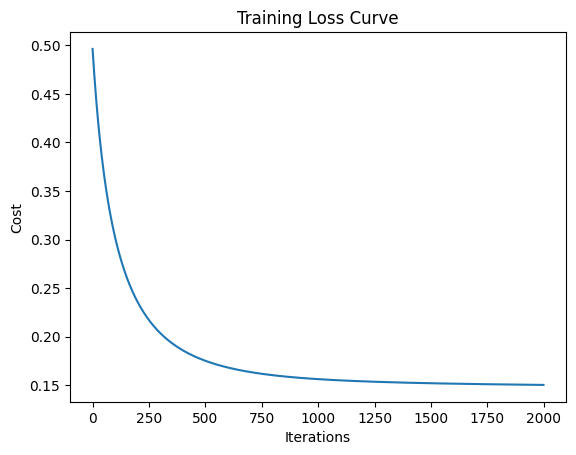

In [36]:
plt.figure()
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Loss Curve")
plt.show()

In [37]:
# bias term
feature_names = ["bias"]

# numeric features (already saved)
feature_names += num_features

# categorical features expanded by one-hot encoding
# ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
# cat_feature_names = ohe.get_feature_names_out(feature_order["categorical"])

# feature_names += list(cat_feature_names)

for name, value in zip(feature_names, theta_final):
    print(name, ":", value)

bias : 0.024697844271232325
longitude : -0.2630956263066371
latitude : -0.259428039459421
housing_median_age : 0.0859711669783503
rooms_per_household : 0.018864247535718203
bedrooms_per_room : 0.19203169456060656
total_rooms_log1p : 0.1007320125190006
total_bedrooms_log1p : 0.11561361606676682
population_log1p : -0.30458688017201113
households_log1p : 0.14119761949991108
median_income_log1p : 0.6893515265158735


In [38]:
with open("../models/linear_regression_theta.pkl", "wb") as f:
    pickle.dump(
        {
            "theta": theta,
            "y_mean": y_mean,
            "y_std": y_std
        },
        f
    )